In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import re
import numpy as np
import json
import urllib.request 
import glob
import seaborn as sns

# to keep my paths secret
import xscen as xs
from xscen import CONFIG
xs.load_config('paths.yml', verbose=(__name__ == '__main__'), reset=True)


In [2]:

# import requests
# import time
# import pandas as pd



# def get_datacite_citations(doi):
#     url = f"https://api.datacite.org/dois/{doi}"
#     try:
#         r = requests.get(url)
#         r.raise_for_status()
#         data = r.json()
#         return data["data"]["attributes"].get("citationCount", 0)
#     except Exception as e:
#         print(f"Error with {doi}: {e}")
#         return None

# path=f"{CONFIG['dir']}/citations/CMIP6_Data_References.csv"
# df=pd.read_csv(path, encoding="latin1")
# #df=df[df['EXPERIMENT_ID'].isnull()] # start with only source
# results = []
# for index, row in df.iterrows():
#     doi=row['DOI'].replace('https://doi.org/','')
#     results.append(get_datacite_citations(doi))
    
# df['num_citation']=results
# display(df)
# df.to_csv(path)

In [3]:
df_ref= pd.read_csv(f"{CONFIG['dir']}/citations/CMIP6_Data_References.csv")
df_ref

,Unnamed: 0,DRS_ID,MIP_ERA,ACTIVITY_ID,INSTITUTION_ID,SOURCE_ID,EXPERIMENT_ID,DOI,Data Reference,License,License Uri,num_citation
0,0,CMIP6.AerChemMIP.AS-RCEC.TaiESM1,CMIP6,AerChemMIP,AS-RCEC,TaiESM1,NaN,https://doi.org/10.22033/ESGF/CMIP6.9682,"Tsai, I-Chun; Lee, Wei-Liang; Hsu, Huang-Hsiun...",CC BY 4.0,https://creativecommons.org/licenses/by/4.0/,3.0
1,1,CMIP6.AerChemMIP.AS-RCEC.TaiESM1.hist-piNTCF,CMIP6,AerChemMIP,AS-RCEC,TaiESM1,hist-piNTCF,https://doi.org/10.22033/ESGF/CMIP6.9744,"Tsai, I-Chun; Lee, Wei-Liang; Hsu, Huang-Hsiun...",CC BY 4.0,https://creativecommons.org/licenses/by/4.0/,0.0
2,2,CMIP6.AerChemMIP.AS-RCEC.TaiESM1.histSST,CMIP6,AerChemMIP,AS-RCEC,TaiESM1,histSST,https://doi.org/10.22033/ESGF/CMIP6.9747,"Tsai, I-Chun; Lee, Wei-Liang; Hsu, Huang-Hsiun...",CC BY 4.0,https://creativecommons.org/licenses/by/4.0/,0.0
3,3,CMIP6.AerChemMIP.AS-RCEC.TaiESM1.histSST-piNTCF,CMIP6,AerChemMIP,AS-RCEC,TaiESM1,histSST-piNTCF,https://doi.org/10.22033/ESGF/CMIP6.9752,"Tsai, I-Chun; Lee, Wei-Liang; Hsu, Huang-Hsiun...",CC BY 4.0,https://creativecommons.org/licenses/by/4.0/,0.0
4,4,CMIP6.AerChemMIP.AS-RCEC.TaiESM1.piClim-NTCF,CMIP6,AerChemMIP,AS-RCEC,TaiESM1,piClim-NTCF,https://doi.org/10.22033/ESGF/CMIP6.9790,"Tsai, I-Chun; Lee, Wei-Liang; Hsu, Huang-Hsiun...",CC BY 4.0,https://creativecommons.org/licenses/by/4.0/,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3004,3004,input4MIPs.CMIP6.ScenarioMIP.UofMD.UofMD-landS...,input4MIPs,CMIP6,ScenarioMIP,UofMD,UofMD-landState-MAGPIE-ssp534-2-1-e,https://doi.org/10.22033/ESGF/input4MIPs.10922,"Hurtt, George; Chini, Louise; Sahajpal, Ritvik...",CC BY-SA 4.0,http://creativecommons.org/licenses/by-sa/4.0/,0.0
3005,3005,input4MIPs.CMIP6.ScenarioMIP.UofMD.UofMD-landS...,input4MIPs,CMIP6,ScenarioMIP,UofMD,UofMD-landState-MAGPIE-ssp534-2-1-f,https://doi.org/10.22033/ESGF/input4MIPs.9949,"Hurtt, George; Chini, Louise; Sahajpal, Ritvik...",CC BY-SA 4.0,http://creativecommons.org/licenses/by-sa/4.0/,0.0
3006,3006,input4MIPs.CMIP6.ScenarioMIP.UofMD.UofMD-landS...,input4MIPs,CMIP6,ScenarioMIP,UofMD,UofMD-landState-MAGPIE-ssp585-2-1-e,https://doi.org/10.22033/ESGF/input4MIPs.10923,"Hurtt, George; Chini, Louise; Sahajpal, Ritvik...",CC BY-SA 4.0,http://creativecommons.org/licenses/by-sa/4.0/,0.0
3007,3007,input4MIPs.CMIP6.ScenarioMIP.UofMD.UofMD-landS...,input4MIPs,CMIP6,ScenarioMIP,UofMD,UofMD-landState-MAGPIE-ssp585-2-1-f,https://doi.org/10.22033/ESGF/input4MIPs.1662,"Hurtt, George; Chini, Louise; Sahajpal, Ritvik...",CC BY-SA 4.0,http://creativecommons.org/licenses/by-sa/4.0/,2.0


In [4]:
df_ref.num_citation.sum()

27456.0

In [5]:
#downloaded
df_source= pd.read_csv(f"{CONFIG['dir']}/cmcc/cmip6-sources_13_01_2025.csv")
display(df_source)
# published
df_model= pd.read_csv(f"{CONFIG['dir']}/cmcc/cmip6-models_13_01_2025.csv")
display(df_model)

,source_id_name,number_of_downloads,total_size_GB
0,EC-EARTH3,70435077,5091534.63
1,IPSL-CM6A-LR,2965261,3845623.97
2,MPI-ESM1-2-HR,6702396,3490023.05
3,CESM2,2925271,2611059.73
4,EC-EARTH3-VEG,26135094,2261190.15
...,...,...,...
140,PICLIM-BC,4,0.00
141,2BANDS,6,0.00
142,PICLIM-SO2,3,0.00
143,PICLIM-OC,3,0.00


,dimension,number_of_datasets,total_size_TB
0,4AOP-v1-5,12,0.00
1,ACCESS-CM2,49179,165.98
2,ACCESS-ESM1-5,323856,670.33
3,ACCESS-OM2,608,5.77
4,ACCESS-OM2-025,214,24.18
...,...,...,...
122,TaiESM1-TIMCOM,198,2.71
123,TaiESM1-TIMCOM2,169,2.28
124,UKESM1-0-LL,218607,743.47
125,UKESM1-1-LL,2445,6.44


# source

In [6]:
# sum all the only source data
df_refsource=df_ref[df_ref['EXPERIMENT_ID'].isnull()].groupby('SOURCE_ID')['num_citation'].sum().reset_index()
df_refsource['SOURCE_ID_CAP']=pd.DataFrame(df_refsource['SOURCE_ID'].str.upper())
#align names
df_source=df_source.rename(columns={'source_id_name': 'SOURCE_ID_CAP', 'total_size_GB': 'total_size_GB_downloaded'})
df_model=df_model.rename(columns={'dimension': 'SOURCE_ID', 'total_size_TB':'total_size_TB uploaded'})
#merge
df_refsource= pd.merge(df_refsource,df_source, on='SOURCE_ID_CAP', )
df_refsource= pd.merge(df_model,df_refsource, on='SOURCE_ID')
df_refsource

,SOURCE_ID,number_of_datasets,total_size_TB uploaded,num_citation,SOURCE_ID_CAP,number_of_downloads,total_size_GB_downloaded
0,4AOP-v1-5,12,0.00,0.0,4AOP-V1-5,304,0.11
1,ACCESS-CM2,49179,165.98,38.0,ACCESS-CM2,1078208,594693.43
2,ACCESS-ESM1-5,323856,670.33,61.0,ACCESS-ESM1-5,2865244,1259006.45
3,ACCESS-OM2,608,5.77,4.0,ACCESS-OM2,14494,3446.97
4,ACCESS-OM2-025,214,24.18,3.0,ACCESS-OM2-025,30275,20201.69
...,...,...,...,...,...,...,...
121,TaiESM1-TIMCOM,198,2.71,0.0,TAIESM1-TIMCOM,473,1080.37
122,TaiESM1-TIMCOM2,169,2.28,0.0,TAIESM1-TIMCOM2,531,1428.01
123,UKESM1-0-LL,218607,743.47,70.0,UKESM1-0-LL,1243827,965355.79
124,UKESM1-1-LL,2445,6.44,2.0,UKESM1-1-LL,4171,2470.39


Text(0.5, 1.0, 'source')

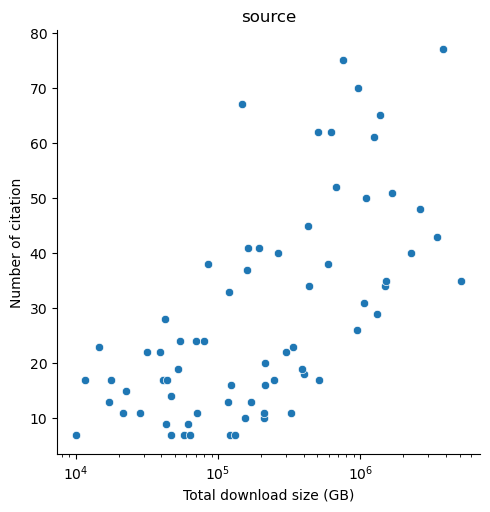

In [7]:



g = sns.relplot(
    data=df_refsource[df_refsource['num_citation']>5],
    x="total_size_GB_downloaded", y="num_citation",
    sizes=(10, 200),
)


g.set(xscale="log",xlabel="Total download size (GB)",ylabel="Number of citation")
plt.title('source')

# experiment

In [8]:
df_exp= pd.read_csv(f"{CONFIG['dir']}/cmcc/cmip6-experiments_13_01_2025.csv")
# sum all the only source data
df_refexp=df_ref[~df_ref['EXPERIMENT_ID'].isnull()].groupby('EXPERIMENT_ID')['num_citation'].sum().reset_index()
df_refexp
#align names
df_exp=df_exp.rename(columns={'experiment_name': 'EXPERIMENT_ID', 'total_size_GB': 'total_size_GB_downloaded'})
#merge
df_refexp= pd.merge(df_refexp,df_exp, on='EXPERIMENT_ID', )
df_refexp

,EXPERIMENT_ID,num_citation,number_of_downloads,total_size_GB_downloaded
0,abrupt-solm4p,0.0,4230,3705.70
1,abrupt-solp4p,0.0,5682,4415.05
2,amip,464.0,1527968,984812.30
3,amip-hist,65.0,43135,21511.14
4,amip-hld,0.0,412,149.36
...,...,...,...,...
70,ssp585-withism,0.0,3834,836.36
71,volc-long-eq,1.0,4538,433.36
72,volc-pinatubo-full,0.0,7531,151.26
73,volc-pinatubo-strat,0.0,1107,21.04


Text(0.5, 1.0, 'Experiment')

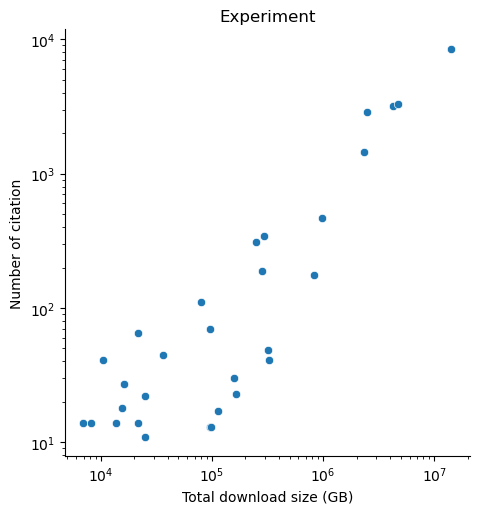

In [9]:
g = sns.relplot(
    data=df_refexp[df_refexp['num_citation']>10],
    x="total_size_GB_downloaded", y="num_citation",
)


g.set(xscale="log",yscale='log',xlabel="Total download size (GB)",ylabel="Number of citation")
plt.title("Experiment")

[None,
 None,
 Text(0.5, 0, 'Total size of downloads on ESGF (GB)'),
 Text(0, 0.5, 'Number of citation'),
 Text(0.5, 1.0, 'b) Experiment')]

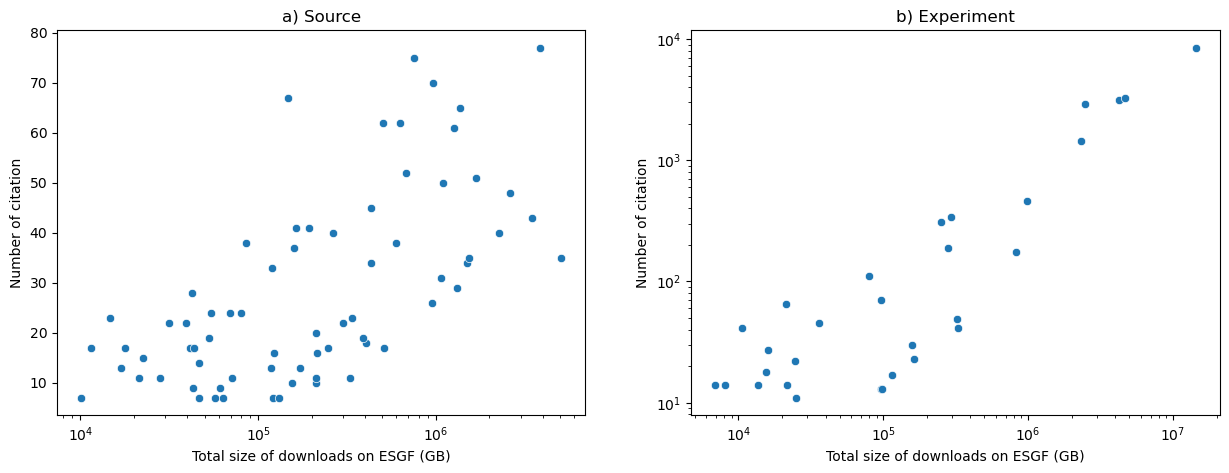

In [11]:
fig, axs= plt.subplots(1,2,figsize=(15,5))


g=sns.scatterplot(
    data=df_refsource[df_refsource['num_citation']>5],
    x="total_size_GB_downloaded", y="num_citation",
    ax=axs[0]
)
g.set(xscale="log",xlabel="Total size of downloads on ESGF (GB)",ylabel="Number of citation", title='a) Source')

g = sns.scatterplot(
    data=df_refexp[df_refexp['num_citation']>10],
    x="total_size_GB_downloaded", y="num_citation",ax=axs[1]
)
g.set(xscale="log",yscale='log',xlabel="Total size of downloads on ESGF (GB)",ylabel="Number of citation", title='b) Experiment')

# axs[0].set_xscale('log')
# axs[0].set_xlabel("Total download size (GB)")
# axs[0].set_ylabel("Number of citation")
#g.set(xscale="log",xlabel="Total download size (GB)",ylabel="Number of citation")
#plt.title('source')

In [68]:
df_refsource.sort_values("num_citation")

,SOURCE_ID,number_of_datasets,total_size_TB uploaded,num_citation,SOURCE_ID_CAP,number_of_downloads,total_size_GB_downloaded
0,4AOP-v1-5,12,0.00,0.0,4AOP-V1-5,304,0.11
125,UKESM1-ice-LL,704,1.01,0.0,UKESM1-ICE-LL,134,40.61
15,CESM1-1-CAM5-CMIP5,760958,178.44,0.0,CESM1-1-CAM5-CMIP5,918133,80751.58
109,NICAM16-7S,551,18.44,0.0,NICAM16-7S,11991,5860.54
111,NICAM16-9S,511,49.48,0.0,NICAM16-9S,2755,13092.78
...,...,...,...,...,...,...,...
61,GFDL-ESM4,23262,79.06,65.0,GFDL-ESM4,743414,1376423.86
99,MIROC-ES2L,419156,707.61,67.0,MIROC-ES2L,1791217,146574.76
123,UKESM1-0-LL,218607,743.47,70.0,UKESM1-0-LL,1243827,965355.79
107,MRI-ESM2-0,503612,1302.40,75.0,MRI-ESM2-0,676224,757758.96


In [69]:
df_refsource[df_refsource.SOURCE_ID.str.contains('EC')]

,SOURCE_ID,number_of_datasets,total_size_TB uploaded,num_citation,SOURCE_ID_CAP,number_of_downloads,total_size_GB_downloaded
37,E3SM-1-1-ECA,1847,4.23,11.0,E3SM-1-1-ECA,237200,28113.96
40,EC-Earth3,551873,2294.36,35.0,EC-EARTH3,70435077,5091534.63
41,EC-Earth3-AerChem,24077,233.49,23.0,EC-EARTH3-AERCHEM,5880086,335362.43
42,EC-Earth3-CC,51128,145.02,11.0,EC-EARTH3-CC,10142799,328164.12
43,EC-Earth3-HR,51926,52.15,0.0,EC-EARTH3-HR,96917,15583.18
44,EC-Earth3-LR,2140,30.96,5.0,EC-EARTH3-LR,1431585,53179.99
45,EC-Earth3-Veg,43534,643.80,40.0,EC-EARTH3-VEG,26135094,2261190.15
46,EC-Earth3-Veg-LR,14095,70.90,17.0,EC-EARTH3-VEG-LR,10813346,246272.73
47,EC-Earth3P,5310,78.82,9.0,EC-EARTH3P,1359192,61345.09
48,EC-Earth3P-HR,5068,333.56,18.0,EC-EARTH3P-HR,1392767,403934.09


In [38]:
df_refexp.sort_values("num_citation")

,EXPERIMENT_ID,num_citation,number_of_downloads,total_size_GB_downloaded
0,abrupt-solm4p,0.0,4230,3705.70
1,abrupt-solp4p,0.0,5682,4415.05
14,esm-ssp585-ocn-alk,0.0,186,192.14
15,esm-ssp585-ocn-alk-stop,0.0,41,12.67
16,esm-ssp585ext,0.0,157,38.62
...,...,...,...,...
63,ssp370,1449.0,11002427,2323535.11
54,ssp126,2899.0,10923775,2475419.44
55,ssp245,3164.0,43389071,4272423.51
68,ssp585,3275.0,18729733,4676138.99
